In [15]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


In [16]:
cwd = Path(os.getcwd())
print(cwd)

json_path = cwd / 'WS2_Grating_Eamonn' / 'Results' / 'WS₂, SiO₂, Si 5.1' / 'summary.json'

with open(json_path, 'r') as summary:
    data = json.load(summary)
    # print(data)

C:\Users\whamp\PycharmProjects\research_project


In [4]:
# aim is to plot the mode energies and separation against: period, thickness, filling

# Lists to store filtered data
periods = []
thicknesses = []
mean_energy = []
diff_energy = []

count_length_not_2 = 0
count_not_correct_form = 0
count_correct_form = 0
total = 0

print(data)

# Extract data
for key, value in data.items():
    total += 1
    #print(value)
    # Extract thickness (t) and period (Λ) from the key string
    key_parts = key.split()
    thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
    period = float(key_parts[1].split('=')[1].replace('nm', ''))
    
    # Get the R2 value from fitting info
    keys = list(value['fitting info'].keys())

    if len(keys) < 2:
        count_length_not_2 += 1
        continue
    
   

    temp_vertices:list = []
    temp_thickness:float = None
    temp_period:float = None

    temp_period = float(period)
    temp_thickness = float(thickness)
    
    # Only consider entries with R2 > 0.6
    for i,key in enumerate(keys):
        R2 = value['fitting info'][key]['R2']
        if (abs(R2) > 0.6) and (R2 != 1.0):
            # Extract vertex value from fitting results
            vertex = value['fitting results']['vertices'][i]
            
            # Append data to lists
            temp_vertices.append([key,vertex])
            #print([key,vertex])
            
    if len(temp_vertices) == 2:
        vtc1 = int(temp_vertices[0][0])
        vtc2 = int(temp_vertices[1][0])
        if (vtc1 % 2) > (vtc2 % 2):
            # if the first one is odd and second is even
            count_not_correct_form += 1
            continue
            
        elif (vtc1 % 2) < (vtc2 % 2):
            vtcs: list = [vtc1, vtc2]
            mean_energy.append(np.mean(vtcs))
            # print(temp_vertices, np.diff(vtcs))
            diff_energy.append(float(np.diff(vtcs)[0]))
            periods.append(temp_period)
            thicknesses.append(temp_thickness)
            count_correct_form += 1
            print(key)
            print(value)
        else:
            count_not_correct_form += 1
            continue
    else:
        count_length_not_2 += 1
        continue



{'t=20.0nm Λ=340nm FF=0.70 N=75': {'fitting info': {'1': {'R2': 0.9783218689640576, 'popt': [-0.0380962655914011, 6827.677657018928, 7.298080252265761, 797.644040193985, 0.3295189549672845, 5.20367484367153, 0.020848612506409223]}, '4': {'R2': 1.0, 'popt': [0.010233232525277915, 6840.465433472042, 4.304316588536659, 8203.282142518054, 5.356270814294198e-08, 4.994338006853536, 0.24496635846259038]}, '5': {'R2': 0.9353705715006544, 'popt': [-0.04181941192339375, 7076.500097220513, 0.5000000001071295, 2.712099771980364, 0.10944517030538559, 2.1071055291670473, 0.9999784425845771]}}, 'fitting results': {'vertices': [1.8485726176374588, 1.2374999999999996, 1.4273353543358287], 'asyms': [0.755008447109214, 1.2375000000000014, 1.2250547776464509]}}, 't=20.0nm Λ=360nm FF=0.70 N=75': {'fitting info': {'1': {'R2': 0.9915926962613333, 'popt': [-0.2764011526437892, 6892.704549529216, 6.951356163890288, 854.549671124629, 0.8666303157420616, 2.881410427328266, 0.3834557558953565]}}, 'fitting results

In [5]:
counts = pd.Series([count_length_not_2, count_not_correct_form, count_correct_form, total], index=['len not 2', 'not correct form', 'correct form', 'total'])
counts

len not 2            57
not correct form     84
correct form         56
total               197
dtype: int64

In [6]:

# title = 'Mode separation energy as function of thickness'

# Lists to store filtered data
df = pd.DataFrame(columns=['period', 'thickness', 'filling', 'mean_energy', 'diff_energy'])

# Assuming 'data' is your dictionary with the necessary data
for key, value in data.items():
    # Extract thickness (t) and period (Λ) from the key string
    key_parts = key.split()
    thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
    period = float(key_parts[1].split('=')[1].replace('nm', ''))
    ff = float(key_parts[2].split('=')[1].replace('nm', ''))
    
    # Get the R2 value from fitting info
    keys = list(value['fitting info'].keys())

    if len(keys) < 2:
        continue
    
    temp_vertices = []

    temp_period = float(period)
    temp_thickness = float(thickness)
    temp_filling = float(ff)
    
    # Only consider entries with R2 > 0.6
    for i, key in enumerate(keys):
        R2 = value['fitting info'][key]['R2']
        if abs(R2) > 0.6:
            # Extract vertex value from fitting results
            vertex = value['fitting results']['vertices'][i]
            
            # Append data to temporary list
            temp_vertices.append(vertex)

    if len(temp_vertices) == 2:
        # Calculate mean energy and difference in energy
        mean_energy_value = np.mean(temp_vertices)
        diff_energy_value = np.diff(temp_vertices)[0]
        
        # Create a new row as a dictionary
        new_row = {
            'period': temp_period,
            'thickness': temp_thickness,
            'filling': temp_filling,
            'mean_energy': mean_energy_value,
            'diff_energy': diff_energy_value
        }
        
        # Append the new row to the DataFrame
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df['diff_energy']=df['diff_energy'].apply(np.abs)

# Convert DataFrame columns to numpy arrays if needed
periods = df['period'].to_numpy()
thicknesses = df['thickness'].to_numpy()
filling = df['filling'].to_numpy()
diff_energy = df['diff_energy'].to_numpy()
mean_energy = df['mean_energy'].to_numpy()

df.head(5)


C:\Users\whamp\AppData\Local\Temp\ipykernel_13492\1895520195.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


,period,thickness,filling,mean_energy,diff_energy
0,460.0,20.0,0.78,1.659595,0.146019
1,480.0,20.0,0.74,1.625928,0.131631
2,480.0,20.0,0.78,1.613720,0.129633
3,500.0,20.0,0.74,1.588148,0.129917
4,500.0,20.0,0.78,1.572525,0.129721


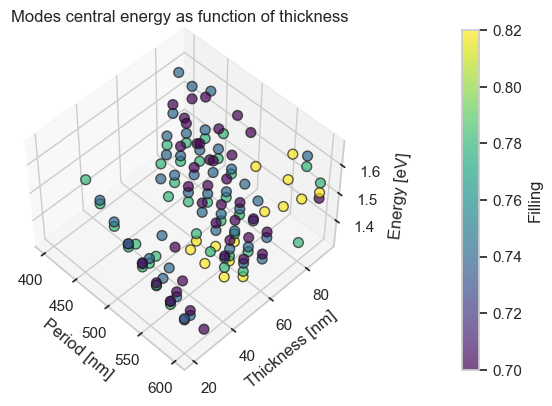

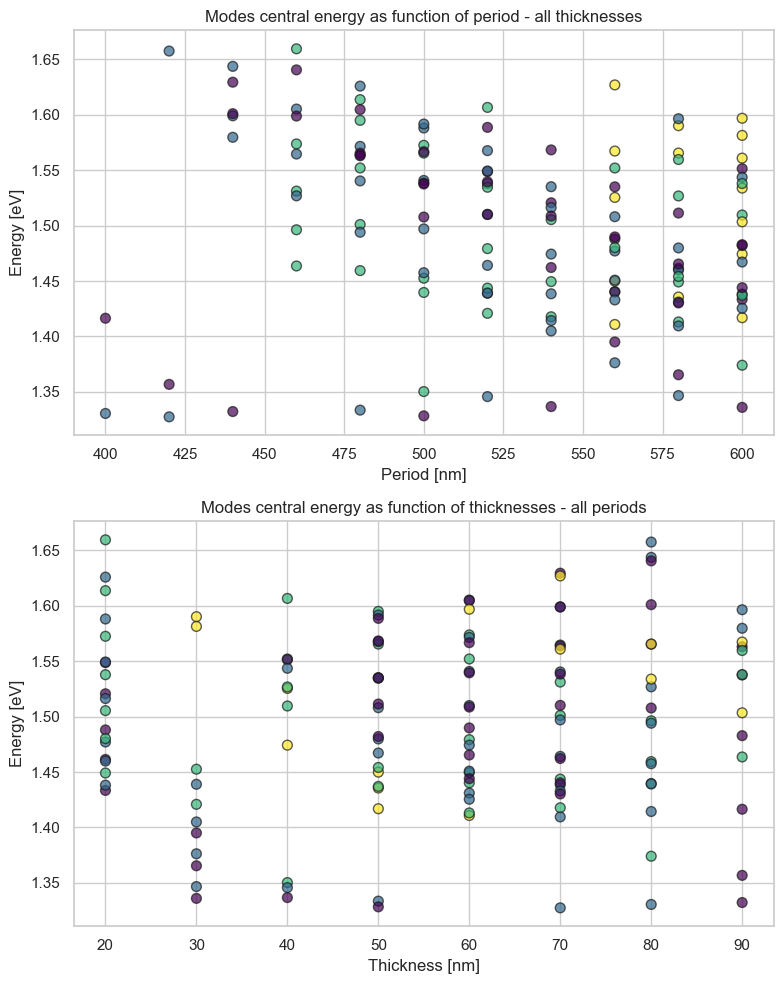

In [13]:
title = 'Modes central energy as function of thickness'

# Create a figure with 2 rows and 1 column for the 3D plot above and 2D plots below
fig = plt.figure(figsize=(12, 15))

p_lab='Period [nm]'
t_lab='Thickness [nm]'
e_lab='Energy [eV]'
f_lab = 'Filling'

# 3D Plot
ax1 = fig.add_subplot(311, projection='3d')
scatter1 = ax1.scatter(periods, thicknesses, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
cbar = fig.colorbar(scatter1)
cbar.set_label(f_lab)
ax1.set_xlabel(p_lab)
ax1.set_ylabel(t_lab)
ax1.set_zlabel(e_lab)
ax1.set_title(title)
ax1.view_init(elev=50, azim=-45)
plt.subplots_adjust(right=2)
#ax1.invert_yaxis()
plt.show()

fig = plt.figure(figsize=(8, 10))
# 2D plot for Period vs Energy
ax2, ax3 = fig.subplots(nrows=2, ncols=1, sharex=False, sharey=False)

scatter2 = ax2.scatter(periods, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel(p_lab)
ax2.set_ylabel(e_lab)
ax2.set_title("Modes central energy as function of period - all thicknesses")

# 2D plot for Thickness vs Energy
scatter3 = ax3.scatter(thicknesses, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax3.set_xlabel(t_lab)
ax3.set_ylabel(e_lab)
ax3.set_title("Modes central energy as function of thicknesses - all periods")
# ax3.invert_xaxis()


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


<Figure size 1500x1000 with 0 Axes>

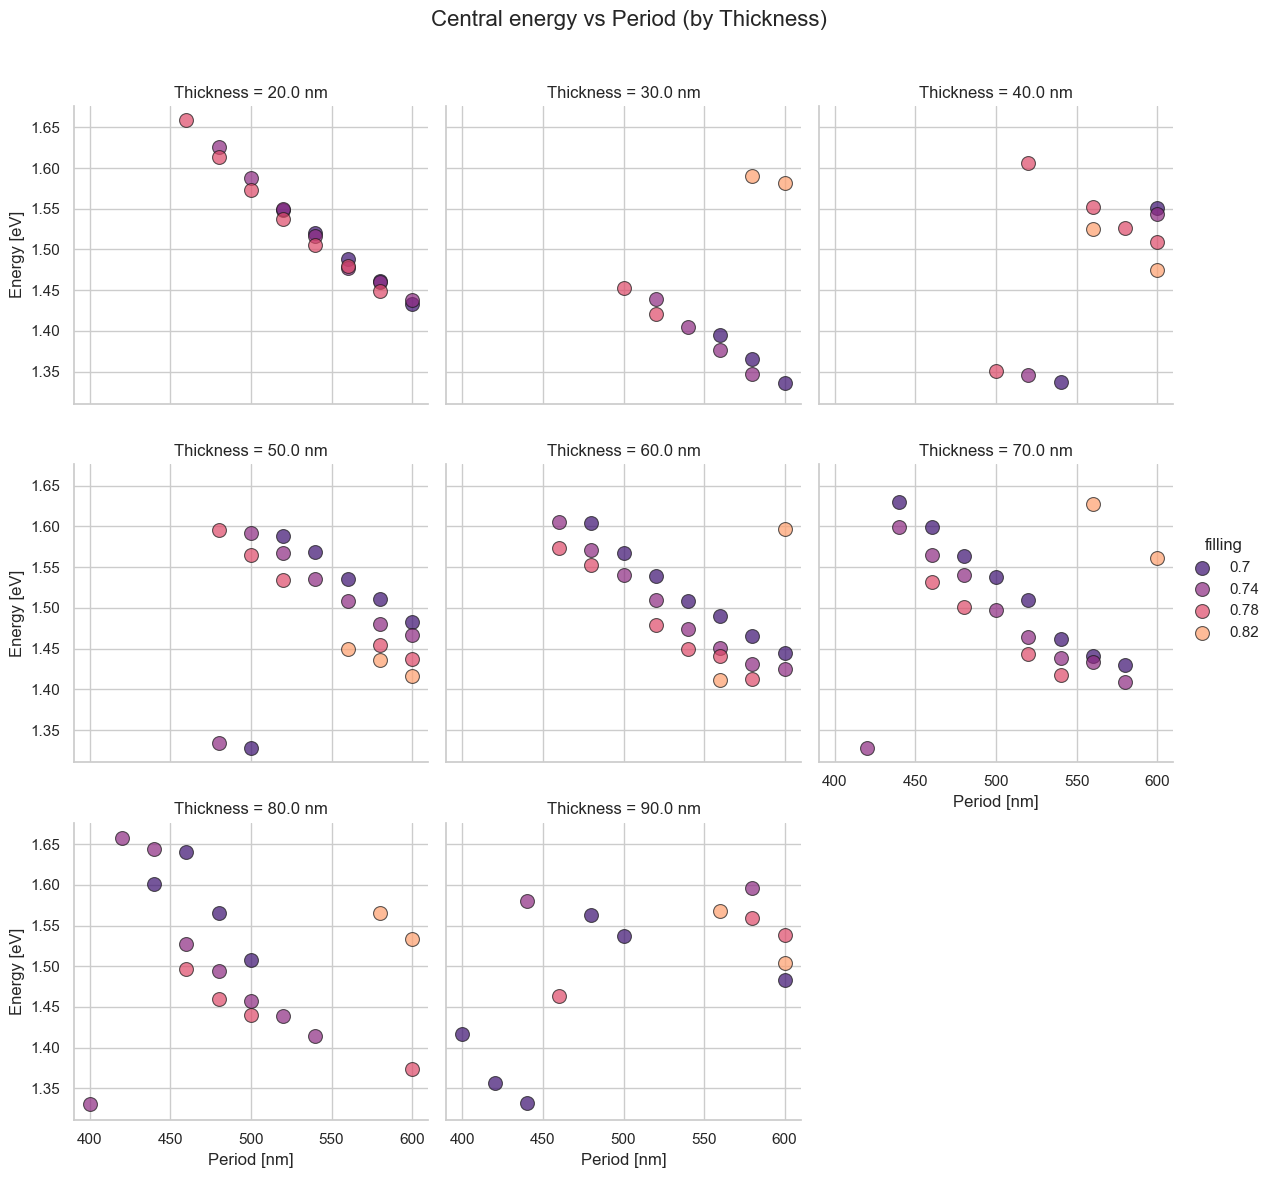

<Figure size 1500x1000 with 0 Axes>

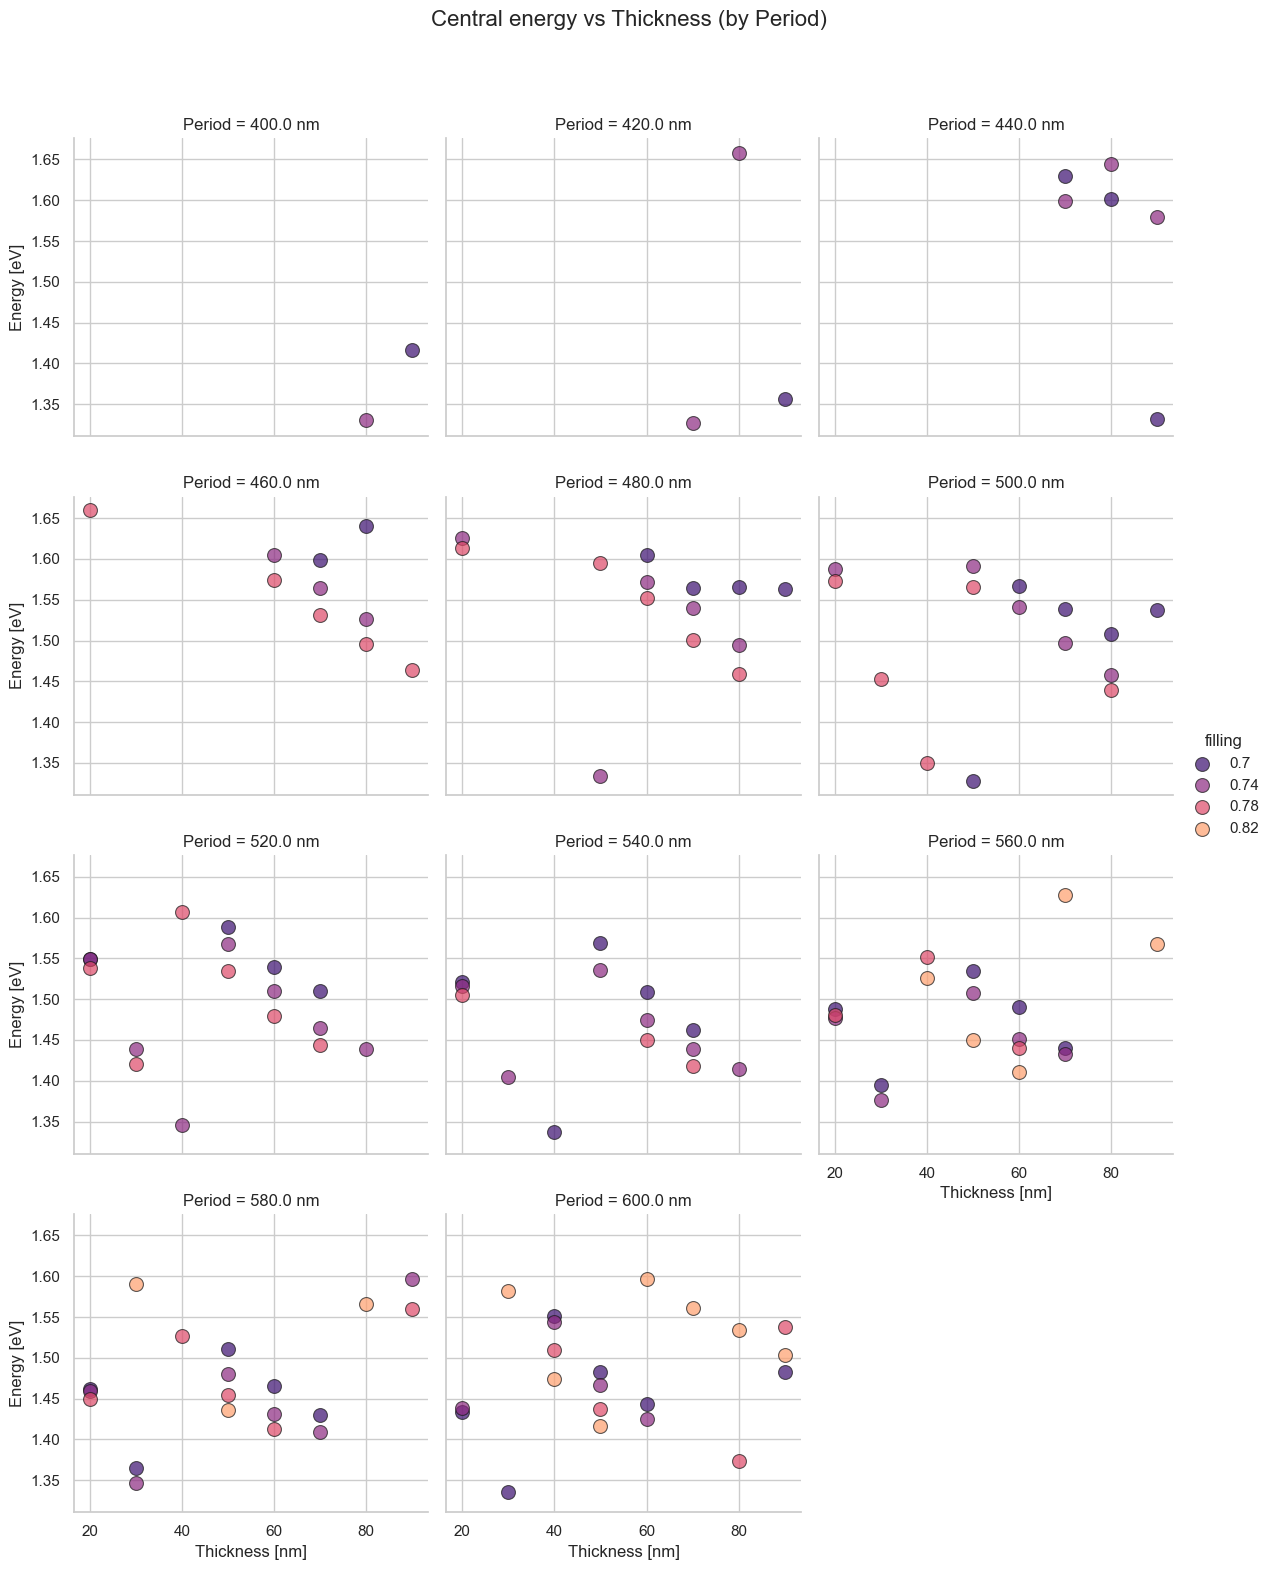

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set_theme(style="whitegrid")

# Create the figure for the 2D plots (Energy vs Period, with Thickness as separate plots)
fig1 = plt.figure(figsize=(15, 10))
g1 = sns.FacetGrid(
    data=df,
    col="thickness", 
    col_wrap=3, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g1.map_dataframe(
    sns.scatterplot, 
    x="period", 
    y="mean_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g1.set_axis_labels(p_lab, e_lab)
g1.set_titles(col_template="Thickness = {col_name} nm")
g1.add_legend()

# Display the Energy vs Period plot grid
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Central energy vs Period (by Thickness)', fontsize=16)
plt.show()

# Create the figure for the 2D plots (Energy vs Thickness, with Period as separate plots)
fig2 = plt.figure(figsize=(15, 10))
g2 = sns.FacetGrid(
    data=df,
    col="period", 
    col_wrap=3, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g2.map_dataframe(
    sns.scatterplot, 
    x="thickness", 
    y="mean_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g2.set_axis_labels(t_lab, e_lab)
g2.set_titles(col_template="Period = {col_name} nm")
g2.add_legend()

# Display the Energy vs Thickness plot grid
plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Central energy vs Thickness (by Period)', fontsize=16)
plt.show()


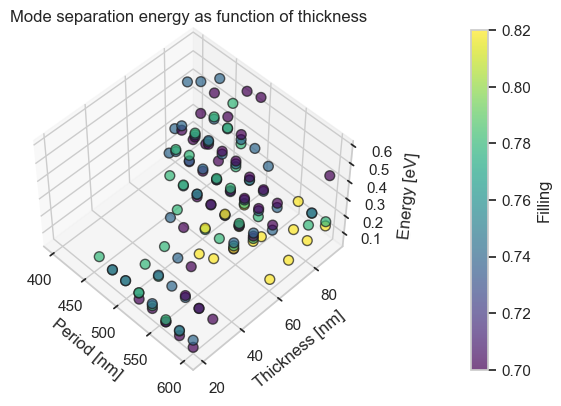

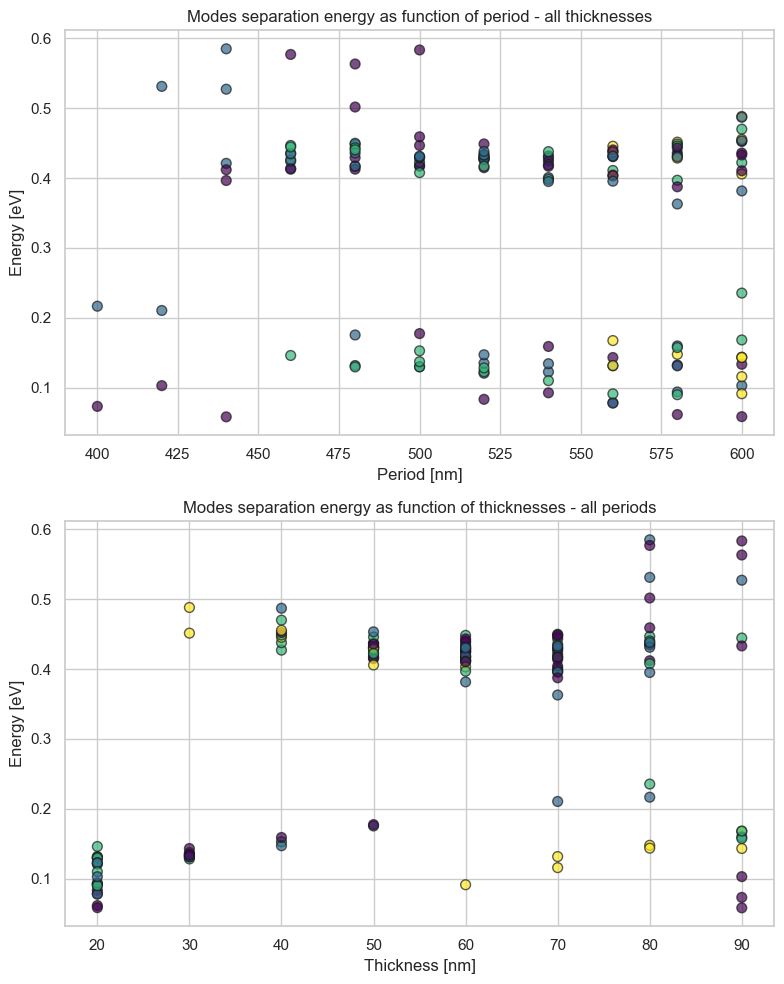

In [14]:

title = 'Mode separation energy as function of thickness'
#  = 'Modes central energy as function of thickness'


fig = plt.figure(figsize=(12, 15))

p_lab='Period [nm]'
t_lab='Thickness [nm]'
e_lab='Energy [eV]'
f_lab = 'Filling'

# 3D Plot
ax1 = fig.add_subplot(311, projection='3d')
scatter1 = ax1.scatter(periods, thicknesses, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
cbar = fig.colorbar(scatter1)
cbar.set_label(f_lab)
ax1.set_xlabel(p_lab)
ax1.set_ylabel(t_lab)
ax1.set_zlabel(e_lab)
ax1.set_title(title)
ax1.view_init(elev=50, azim=-45)
plt.subplots_adjust(right=2)
#ax1.invert_yaxis()
plt.show()

fig = plt.figure(figsize=(8, 10))
# 2D plot for Period vs Energy
ax2, ax3 = fig.subplots(nrows=2, ncols=1, sharex=False, sharey=False)

scatter2 = ax2.scatter(periods, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel(p_lab)
ax2.set_ylabel(e_lab)
ax2.set_title("Modes separation energy as function of period - all thicknesses")

# 2D plot for Thickness vs Energy
scatter3 = ax3.scatter(thicknesses, diff_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax3.set_xlabel(t_lab)
ax3.set_ylabel(e_lab)
ax3.set_title("Modes separation energy as function of thicknesses - all periods")
# ax3.invert_xaxis()


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


<Figure size 1500x1000 with 0 Axes>

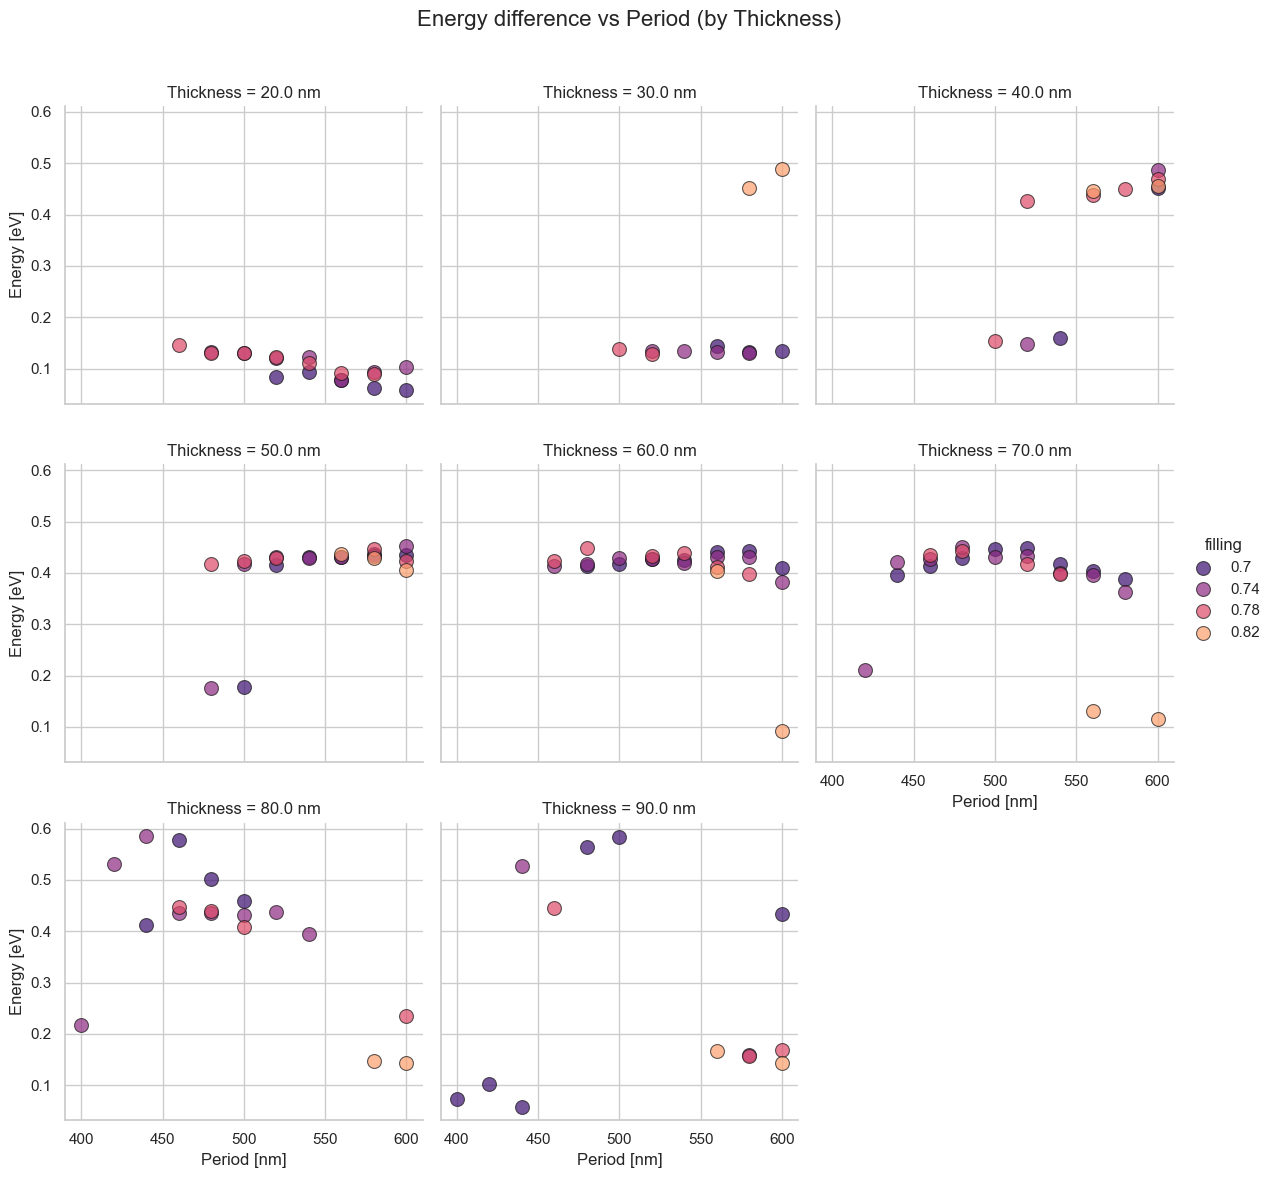

<Figure size 1500x1000 with 0 Axes>

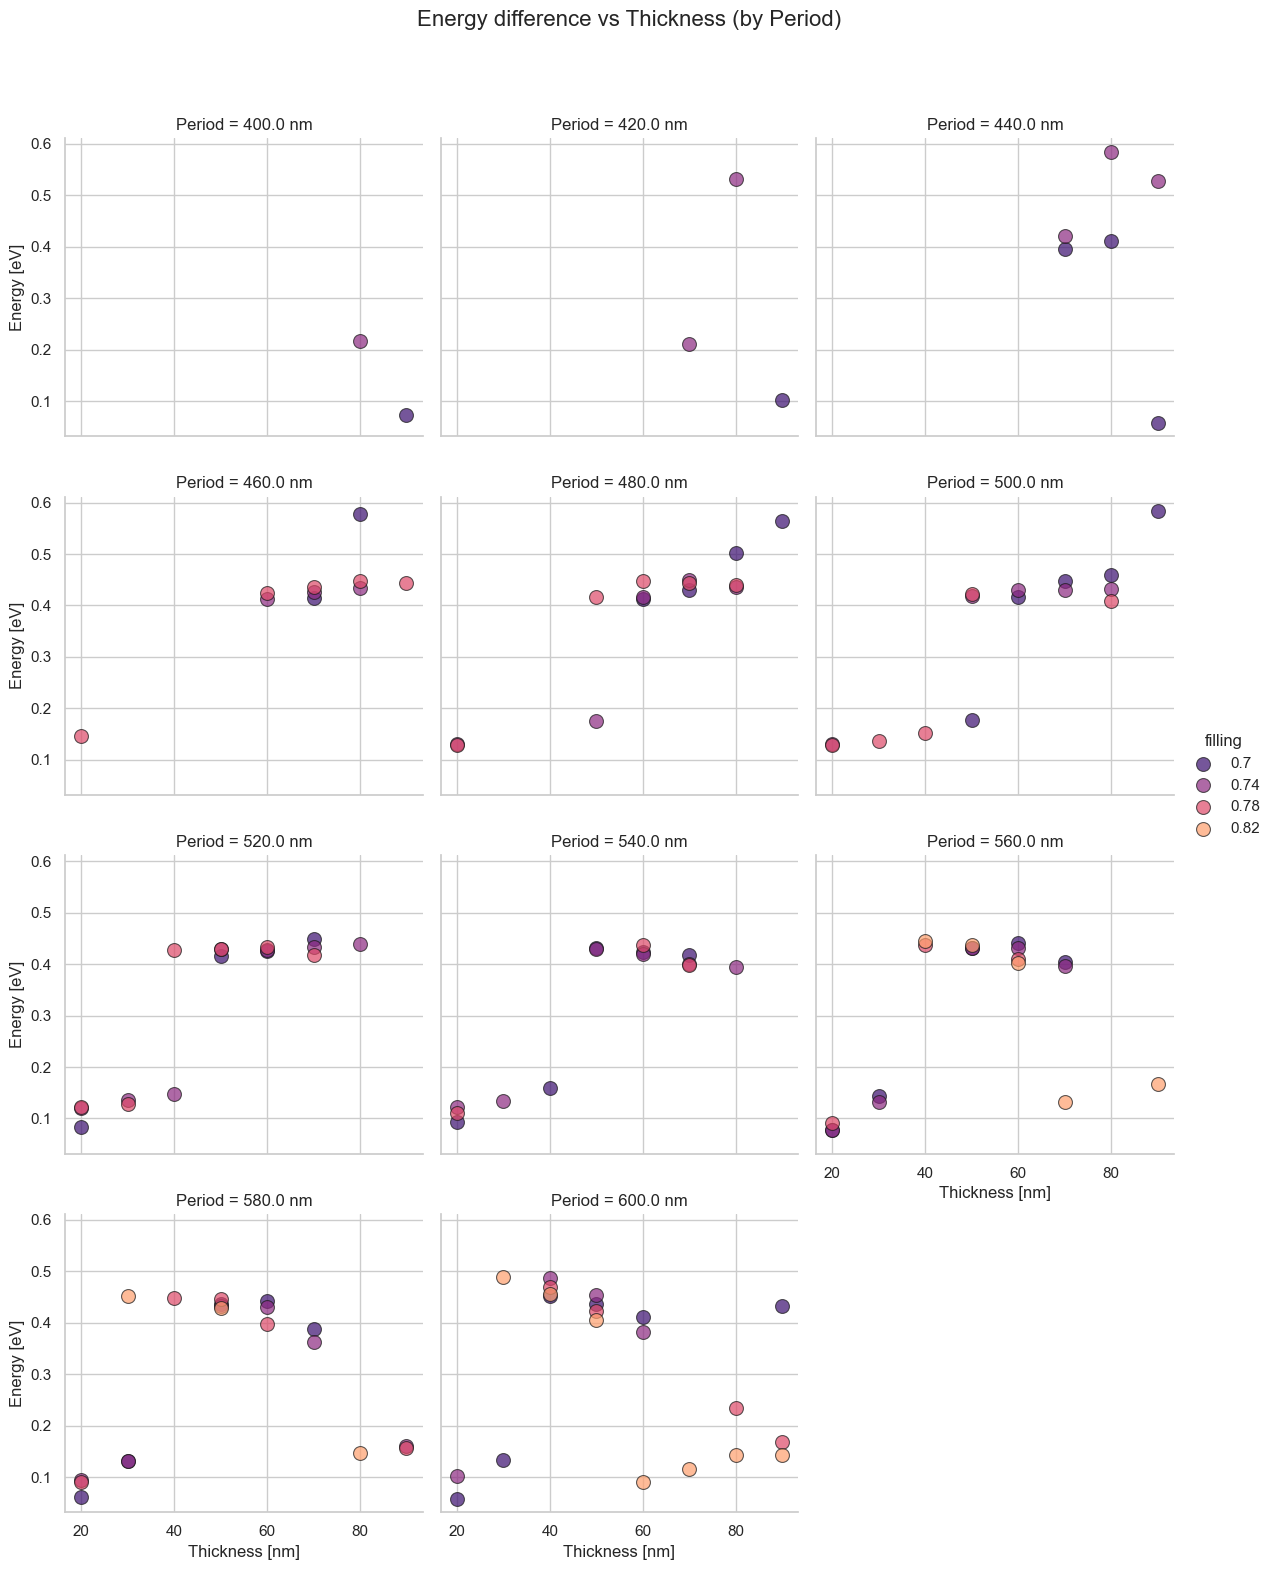

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set_theme(style="whitegrid")

# Create the figure for the 2D plots (Energy vs Period, with Thickness as separate plots)
fig1 = plt.figure(figsize=(15, 10))
g1 = sns.FacetGrid(
    data=df,
    col="thickness", 
    col_wrap=3, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g1.map_dataframe(
    sns.scatterplot, 
    x="period", 
    y="diff_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g1.set_axis_labels(p_lab, e_lab)
g1.set_titles(col_template="Thickness = {col_name} nm")
g1.add_legend()

# Display the Energy vs Period plot grid
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Energy difference vs Period (by Thickness)', fontsize=16)
plt.show()

# Create the figure for the 2D plots (Energy vs Thickness, with Period as separate plots)
fig2 = plt.figure(figsize=(15, 10))
g2 = sns.FacetGrid(
    data=df,
    col="period", 
    col_wrap=3, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g2.map_dataframe(
    sns.scatterplot, 
    x="thickness", 
    y="diff_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g2.set_axis_labels(t_lab, e_lab)
g2.set_titles(col_template="Period = {col_name} nm")
g2.add_legend()

# Display the Energy vs Thickness plot grid
plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Energy difference vs Thickness (by Period)', fontsize=16)
plt.show()


In [11]:
print()